In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mnist = keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 [==============================] - 105s 9us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


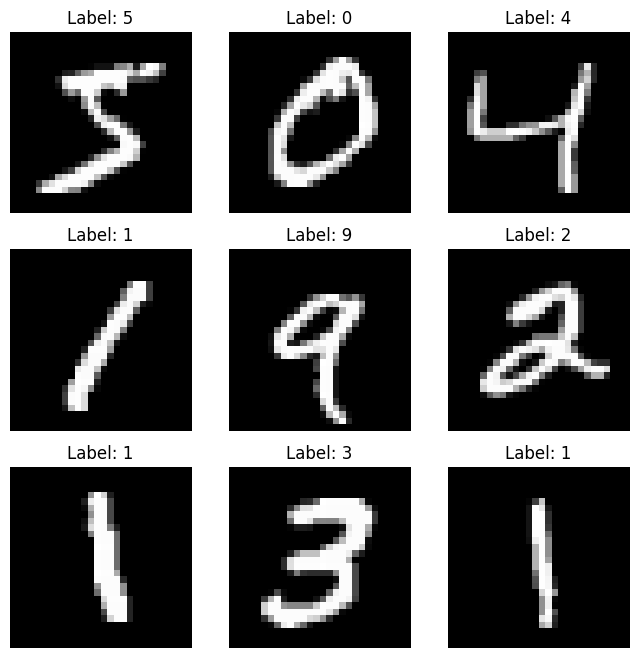

In [3]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Functional API

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_functional_model():
    
    inputs = layers.Input(shape=(28, 28), name="digit_input")

    x = layers.Flatten()(inputs)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x) 
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(10, activation='softmax', name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="mnist_model")
    
    return model

model = build_functional_model()

# Training

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 [==============================] - 5s 2ms/step - loss: 0.2744 - accuracy: 0.9225 - val_loss: 0.1265 - val_accuracy: 0.9633
Epoch 2/10
1688/1688 [==============================] - 4s 2ms/step - loss: 0.1214 - accuracy: 0.9638 - val_loss: 0.0956 - val_accuracy: 0.9708
Epoch 3/10
1688/1688 [==============================] - 4s 2ms/step - loss: 0.0839 - accuracy: 0.9748 - val_loss: 0.0848 - val_accuracy: 0.9755
Epoch 4/10
1688/1688 [==============================] - 4s 2ms/step - loss: 0.0623 - accuracy: 0.9813 - val_loss: 0.0831 - val_accuracy: 0.9740
Epoch 5/10
1688/1688 [==============================] - 4s 2ms/step - loss: 0.0481 - accuracy: 0.9851 - val_loss: 0.0828 - val_accuracy: 0.9765
Epoch 6/10
1688/1688 [==============================] - 4s 2ms/step - loss: 0.0385 - accuracy: 0.9877 - val_loss: 0.0757 - val_accuracy: 0.9783
Epoch 7/10
1688/1688 [==============================] - 4s 2ms/step - loss: 0.0291 - accuracy: 0.9914 - val_loss: 0.0886 - val_accuracy:

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 [==============================] - 0s 1ms/step - loss: 0.0828 - accuracy: 0.9791
Test Accuracy: 0.9790999889373779


313/313 [==============================] - 0s 1ms/step


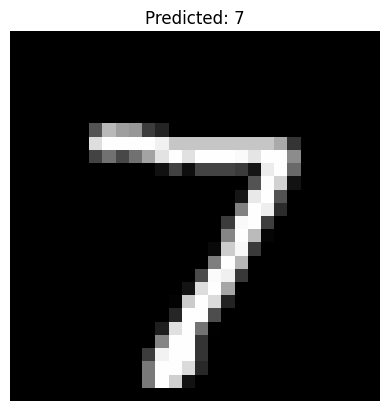

In [9]:
predictions = model.predict(x_test)

plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])}")
plt.axis('off')
plt.show()

# CNN model

In [ ]:
model = keras.Sequential([

    keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Conv2D(32, (3,3), padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3,3), padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(128),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks
)